# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [13]:
#Your code here :

# Define column names
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Read the CSV file with custom column names and delimiter
data = pd.read_csv(r"C:\Users\sombe\Downloads\housing.csv", header=None, delimiter=r"\s+", names=column_names)

# Display the first few rows of the dataframe
print(data.head())



      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [3]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [4]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [15]:
# Your code here :

from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
X = data.drop('MEDV', axis=1)  # Features (all columns except 'MEDV')
y = data['MEDV']  # Target (the 'MEDV' column)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting data sets
print(f"Training set X shape: {X_train.shape}, Training set y shape: {y_train.shape}")
print(f"Testing set X shape: {X_test.shape}, Testing set y shape: {y_test.shape}")


Training set X shape: (404, 13), Training set y shape: (404,)
Testing set X shape: (102, 13), Testing set y shape: (102,)


## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [17]:
# Your code here :

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on both the training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Display the first few predictions for both sets
print("First few predictions on the training set:")
print(y_train_pred[:5])

print("\nFirst few predictions on the testing set:")
print(y_test_pred[:5])

# Calculate and display the Mean Squared Error and R-squared for both training and testing sets
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTraining set performance:")
print(f"Mean Squared Error: {train_mse}")
print(f"R-squared: {train_r2}")

print("\nTesting set performance:")
print(f"Mean Squared Error: {test_mse}")
print(f"R-squared: {test_r2}")


First few predictions on the training set:
[10.96952405 19.41196567 23.06419602 12.1470648  18.3738116 ]

First few predictions on the testing set:
[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]

Training set performance:
Mean Squared Error: 21.641412753226312
R-squared: 0.7508856358979673

Testing set performance:
Mean Squared Error: 24.291119474973613
R-squared: 0.6687594935356307


## 3. Calculate and print R-squared for both the training and the testing set.

In [21]:
# Your code here :

# Initialize and train the LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on both the training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate R-squared for both training and testing sets
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print the R-squared values
print(f"Training set R-squared: {train_r2}")
print(f"Testing set R-squared: {test_r2}")


Training set R-squared: 0.7508856358979673
Testing set R-squared: 0.6687594935356307


## 4. Calculate and print mean squared error for both the training and the testing set.

In [23]:
# Your code here :

# Initialize and train the LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on both the training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate Mean Squared Error for both training and testing sets
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the Mean Squared Error values
print(f"Training set Mean Squared Error: {train_mse}")
print(f"Testing set Mean Squared Error: {test_mse}")


Training set Mean Squared Error: 21.641412753226312
Testing set Mean Squared Error: 24.291119474973613


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [25]:
# Your code here :
 
from sklearn.metrics import mean_absolute_error

# Initialize and train the LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on both the training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate Mean Absolute Error for both training and testing sets
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print the Mean Absolute Error values
print(f"Training set Mean Absolute Error: {train_mae}")
print(f"Testing set Mean Absolute Error: {test_mae}")


Training set Mean Absolute Error: 3.314771626783227
Testing set Mean Absolute Error: 3.189091965887852


## Classification Model Evaluation

In [27]:
from sklearn.datasets import load_iris
data = load_iris()

In [29]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [43]:
column_names = data.feature_names

In [45]:
df = pd.DataFrame(data['data'],columns=column_names)

In [47]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [49]:
target = pd.DataFrame(data.target)

In [51]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [53]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [62]:
# Your code here :

from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
X = data.data  # Features
y = data.target  # Target (the 'class' column)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting data sets
print(f"Training set X shape: {X_train.shape}, Training set y shape: {y_train.shape}")
print(f"Testing set X shape: {X_test.shape}, Testing set y shape: {y_test.shape}")


Training set X shape: (120, 4), Training set y shape: (120,)
Testing set X shape: (30, 4), Testing set y shape: (30,)


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [75]:
# Your code here :
from sklearn.linear_model import LogisticRegression

# Split the data into features (X) and target (y)
X = data.data  # Features
y = data.target  # Target (the 'class' column)

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the Logistic Regression model
model.fit(X_train, y_train)

# Generate predictions on both the training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("First few predictions on the training set:", y_train_pred[:5])
print("First few predictions on the testing set:", y_test_pred[:5])

First few predictions on the training set: [0 0 1 0 0]
First few predictions on the testing set: [1 0 2 1 1]


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [70]:
# Your code here :

from sklearn.metrics import accuracy_score

# Calculate accuracy for both training and testing sets
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print the accuracy scores
print(f"Training set accuracy: {train_accuracy}")
print(f"Testing set accuracy: {test_accuracy}")


Training set accuracy: 0.975
Testing set accuracy: 1.0


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [81]:
# Your code here :

from sklearn.metrics import balanced_accuracy_score

# Calculate balanced accuracy for the training set 
train_balanced_accuracy = balanced_accuracy_score(y_train, y_train_pred)

# Calculate balanced accuracy for the testing set 
test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)

# Print the results for balanced accuracy
print(f"Training set balanced accuracy: {train_balanced_accuracy}")
print(f"Testing set balanced accuracy: {test_balanced_accuracy}")



Training set balanced accuracy: 0.975609756097561
Testing set balanced accuracy: 1.0


## 10. Calculate and print the precision score for both the training and the testing set.

In [83]:
# Your code here :

from sklearn.metrics import precision_score

# Calculate precision for the training set (comparing true labels and predictions)
train_precision = precision_score(y_train, y_train_pred, average='macro')  # 'macro' for multi-class or use 'binary' for binary classification

# Calculate precision for the testing set (comparing true labels and predictions)
test_precision = precision_score(y_test, y_test_pred, average='macro')  # 'macro' for multi-class or use 'binary' for binary classification

# Print the precision scores for both training and testing sets
print(f"Training set precision: {train_precision}")
print(f"Testing set precision: {test_precision}")


Training set precision: 0.9761904761904763
Testing set precision: 1.0


## 11. Calculate and print the recall score for both the training and the testing set.

In [85]:
# Your code here :

from sklearn.metrics import recall_score

# Calculate recall for the training set (comparing true labels and predictions)
train_recall = recall_score(y_train, y_train_pred, average='macro')  # 'macro' for multi-class or use 'binary' for binary classification

# Calculate recall for the testing set (comparing true labels and predictions)
test_recall = recall_score(y_test, y_test_pred, average='macro')  # 'macro' for multi-class or use 'binary' for binary classification

# Print the recall scores for both training and testing sets
print(f"Training set recall: {train_recall}")
print(f"Testing set recall: {test_recall}")


Training set recall: 0.975609756097561
Testing set recall: 1.0


## 12. Calculate and print the F1 score for both the training and the testing set.

In [87]:
# Your code here :

from sklearn.metrics import f1_score

# Calculate F1 score for the training set (comparing true labels and predictions)
train_f1 = f1_score(y_train, y_train_pred, average='macro')  # 'macro' for multi-class or 'binary' for binary classification

# Calculate F1 score for the testing set (comparing true labels and predictions)
test_f1 = f1_score(y_test, y_test_pred, average='macro')  # 'macro' for multi-class or 'binary' for binary classification

# Print the F1 scores for both training and testing sets
print(f"Training set F1 score: {train_f1}")
print(f"Testing set F1 score: {test_f1}")


Training set F1 score: 0.974996093139553
Testing set F1 score: 1.0


## 13. Generate confusion matrices for both the training and the testing set.

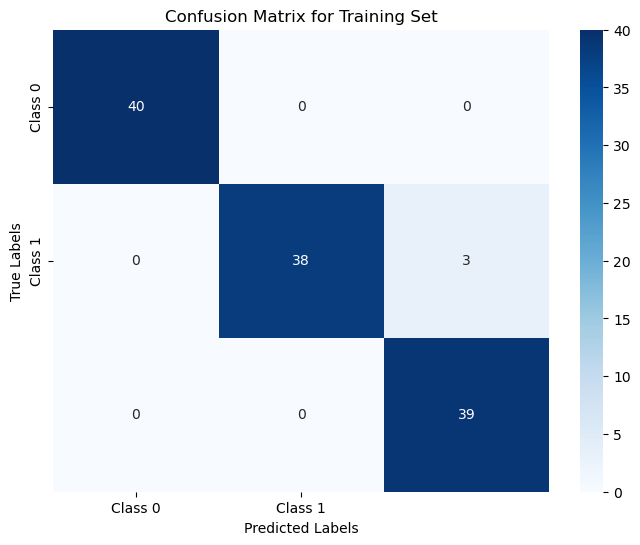

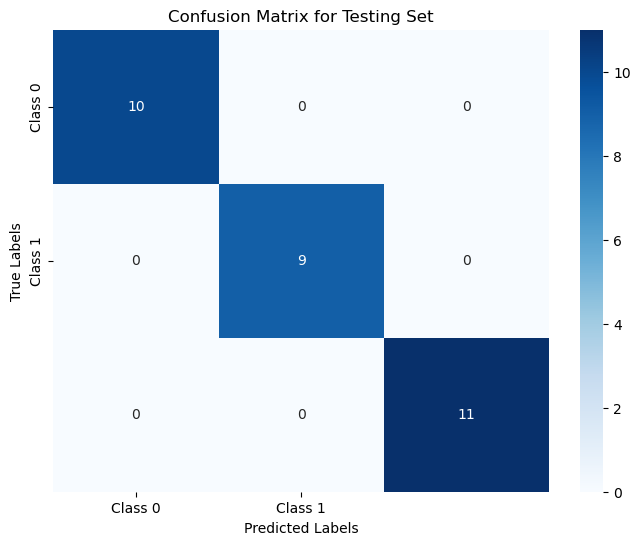

In [89]:
# Your code here :

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix for the training set
train_conf_matrix = confusion_matrix(y_train, y_train_pred)

# Calculate confusion matrix for the testing set
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix for the training set
plt.figure(figsize=(8, 6))
sns.heatmap(train_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix for Training Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Plot confusion matrix for the testing set
plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix for Testing Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [26]:
# Have fun here !